eta_star = 281.21 Mpc
r_s(eta_star) = 144.87 Mpc
k_D(eta_star) = 0.2560 Mpc^-1  (x_e = 1, tight coupling)
lambda_D      = 3.91 Mpc

Grafico 3a salvo com sucesso.


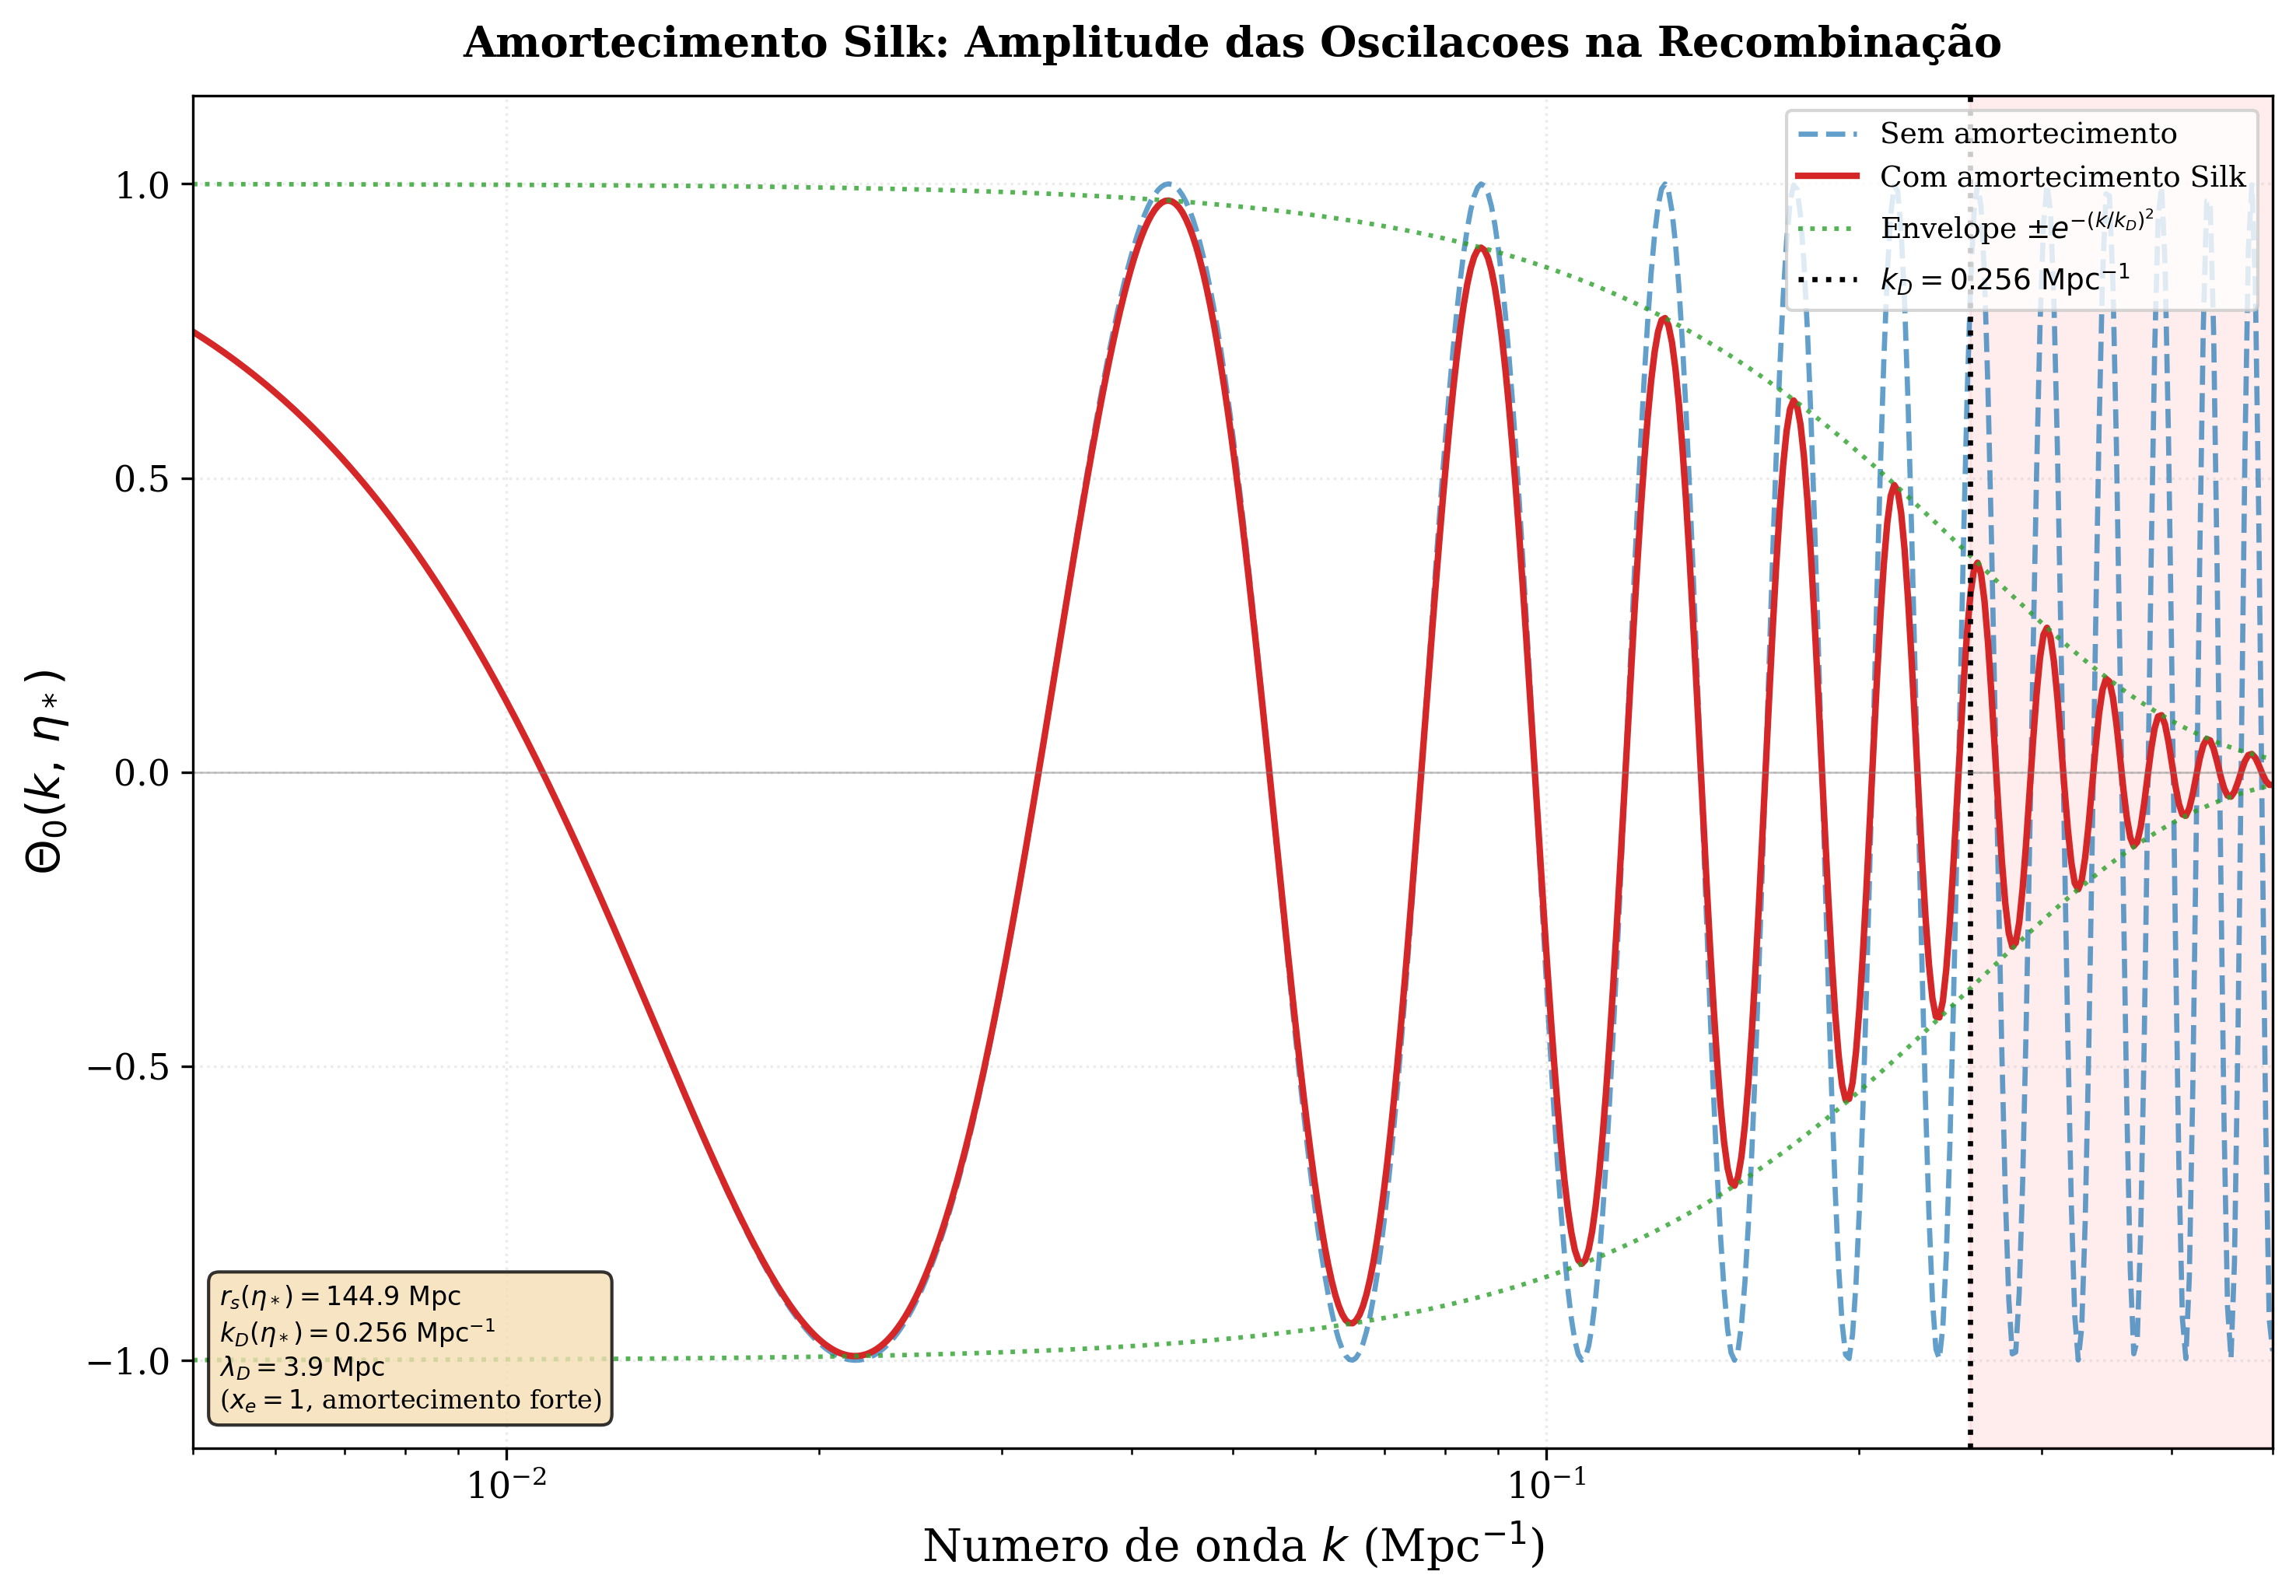


   k      k/k_D    cos(k r_s)  exp[-(k/k_D)^2]  Theta_amort
------------------------------------------------------------
 0.010    0.039      0.1218         0.9985        0.1216  
 0.030    0.117     -0.3582         0.9864       -0.3533  
 0.060    0.234     -0.7434         0.9465       -0.7036  
 0.100    0.391     -0.3425         0.8585       -0.2940  
 0.150    0.586     -0.9661         0.7094       -0.6853  
 0.200    0.781     -0.7654         0.5431       -0.4157  
 0.300    1.172      0.8668         0.2532        0.2195  


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate


# =============================================================================
# CONFIGURACOES DE ESTILO
# =============================================================================

plt.style.use('default')

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'legend.fontsize': 11,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'lines.linewidth': 1.8,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--'
})


# =============================================================================
# PARAMETROS COSMOLOGICOS - Planck 2018
# =============================================================================

Omega_b_h2 = 0.0224
Omega_m = 0.315
h = 0.674

H0_si = h * 100 / 299792.458
Omega_r = 9.0e-5

z_star = 1090
z_max = 1e6


# Secao de choque de Thomson em Mpc^2
sigma_T_Mpc2 = 6.6524e-25 / (3.08567758e24)**2

# Densidade de materia bariônica
Omega_b = Omega_b_h2 / h**2

# Densidade critica atual
rho_crit_0 = 2.77536627e11 * h**2

# Massa do proton em unidades de massa solar
m_H_Msun = 1.6735575e-27 / 1.98892e30

# Numero de barions por Mpc^3 no presente
n_b0_Mpc3 = Omega_b * rho_crit_0 / m_H_Msun


# =============================================================================
# FUNCAO E(z)
# =============================================================================

def E(z):
    """
    Funcao adimensional da expansao cosmologica.
    """

    return np.sqrt(
        Omega_m * (1 + z)**3
        + Omega_r * (1 + z)**4
        + (1 - Omega_m - Omega_r)
    )


# =============================================================================
# TEMPO CONFORME
#
# eta(z) = integral de z ate z_max de dz' / H(z')
# =============================================================================

def eta_c(z):
    """
    Calcula o tempo conforme correspondente ao redshift z.
    """

    integrand = lambda zp: 1 / (H0_si * E(zp))

    value, _ = integrate.quad(
        integrand,
        z,
        z_max,
        limit=500
    )

    return value


# =============================================================================
# GRADE DE REDSHIFT E TEMPO CONFORME
# =============================================================================

N = 5000

z_grid = np.logspace(
    0,
    np.log10(z_max),
    N
)[::-1]


eta_raw = np.array([
    eta_c(z)
    for z in z_grid
])


# Reordena os pontos em ordem crescente de tempo conforme
order = np.argsort(eta_raw)

eta_s = eta_raw[order]
z_s = z_grid[order]


# Tempo conforme na recombinacao
eta_star_val = eta_c(z_star)

idx_star = np.argmin(
    np.abs(eta_s - eta_star_val)
)


print(
    f"eta_star = {eta_star_val:.2f} Mpc"
)


# =============================================================================
# PARAMETROS DO FLUIDO FOTON-BARION
#
# R(eta), velocidade do som e horizonte sonico
# =============================================================================

def R_z(z):
    """
    Funcao R(z) que descreve a razao entre a densidade
    de energia bariônica e a densidade de energia de fotons.
    """

    a_star = 1 / (1 + z_star)

    return (
        0.6
        * (Omega_b_h2 / 0.02)
        * (a_star / 1e-3)
        * (1 + z_star) / (1 + z)
    )


R_g = R_z(z_s)


c_s_g = 1 / np.sqrt(
    3 * (1 + R_g)
)


# Horizonte sonico acumulado
r_s_g = integrate.cumulative_trapezoid(
    c_s_g,
    eta_s,
    initial=0
)


rs_star = r_s_g[idx_star]


print(
    f"r_s(eta_star) = {rs_star:.2f} Mpc"
)


# =============================================================================
# ESCALA DE DAMPING k_D - Eq. 93
#
# Considera x_e = 1 e o regime de tight coupling.
# =============================================================================

a_g = 1 / (1 + z_s)

# Densidade de eletrons para ionizacao completa
ne_g = n_b0_Mpc3 * (1 + z_s)**3

# Taxa de espalhamento de Thomson
tau_p_g = ne_g * sigma_T_Mpc2 * a_g


# Integrando para k_D^{-2}
kD_integrand = (
    1
    / (6 * (1 + R_g) * tau_p_g)
    * (
        R_g**2 / (1 + R_g)
        + 8 / 9
    )
)


kD2_inv = integrate.trapezoid(
    kD_integrand[:idx_star + 1],
    eta_s[:idx_star + 1]
)


kD_star = 1 / np.sqrt(kD2_inv)

lambda_D = 1 / kD_star


print(
    f"k_D(eta_star) = {kD_star:.4f} Mpc^-1"
    "  (x_e = 1, tight coupling)"
)

print(
    f"lambda_D      = {lambda_D:.2f} Mpc"
)


# =============================================================================
# AMPLITUDES
#
# Eq. 92:
#
# Theta_0(k, eta_star)
#     = cos(k r_s) exp[-(k/k_D)^2]
# =============================================================================

k = np.logspace(
    np.log10(0.005),
    np.log10(0.5),
    600
)


# Oscilacao sem amortecimento
theta_undamped = np.cos(
    k * rs_star
)


# Oscilacao com amortecimento de Silk
theta_damped = (
    np.cos(k * rs_star)
    * np.exp(-(k / kD_star)**2)
)


# Envelopes de amortecimento
envelope_pos = np.exp(
    -(k / kD_star)**2
)

envelope_neg = -np.exp(
    -(k / kD_star)**2
)


# =============================================================================
# GRAFICO
# =============================================================================

fig, ax = plt.subplots(
    figsize=(10, 7)
)


# Oscilacao sem amortecimento
ax.plot(
    k,
    theta_undamped,
    label='Sem amortecimento',
    color='#1f77b4',
    linestyle='--',
    linewidth=1.6,
    alpha=0.7
)


# Oscilacao com amortecimento de Silk
ax.plot(
    k,
    theta_damped,
    label='Com amortecimento Silk',
    color='#d62728',
    linestyle='-',
    linewidth=2.0
)


# Envelope superior
ax.plot(
    k,
    envelope_pos,
    color='#2ca02c',
    linestyle=':',
    linewidth=1.4,
    alpha=0.8,
    label=r'Envelope $\pm e^{-(k/k_D)^2}$'
)


# Envelope inferior
ax.plot(
    k,
    envelope_neg,
    color='#2ca02c',
    linestyle=':',
    linewidth=1.4,
    alpha=0.8
)


# Escala k_D
ax.axvline(
    x=kD_star,
    color='black',
    linestyle=':',
    linewidth=1.6,
    label=rf'$k_D = {kD_star:.3f}\ \mathrm{{Mpc}}^{{-1}}$'
)


# Linha horizontal em zero
ax.axhline(
    y=0,
    color='gray',
    linewidth=0.6,
    alpha=0.5
)


# Regiao de amortecimento significativo
ax.axvspan(
    kD_star,
    0.5,
    alpha=0.07,
    color='red'
)


# =============================================================================
# EIXOS E FORMATACAO
# =============================================================================

ax.set_xlabel(
    r'Numero de onda $k$ (Mpc$^{-1}$)',
    fontsize=14
)

ax.set_ylabel(
    r'$\Theta_0(k,\,\eta_*)$',
    fontsize=14
)


ax.set_xscale('log')

ax.set_xlim(
    0.005,
    0.5
)

ax.set_ylim(
    -1.15,
    1.15
)


ax.tick_params(
    labelsize=11
)


ax.legend(
    loc='upper right',
    frameon=True,
    fontsize=9
)


ax.grid(
    True,
    alpha=0.25,
    linestyle=':'
)


ax.set_title(
    'Amortecimento Silk: Amplitude das Oscilacoes na Recombinação',
    fontsize=13,
    fontweight='bold',
    pad=12
)


# =============================================================================
# INFORMACOES NO GRAFICO
# =============================================================================

ax.text(
    0.0125,
    0.025,
    rf'$r_s(\eta_*) = {rs_star:.1f}\ \mathrm{{Mpc}}$' '\n'
    rf'$k_D(\eta_*) = {kD_star:.3f}\ \mathrm{{Mpc}}^{{-1}}$' '\n'
    rf'$\lambda_D = {lambda_D:.1f}\ \mathrm{{Mpc}}$' '\n'
    r'($x_e = 1$, amortecimento forte)',
    transform=ax.transAxes,
    bbox=dict(
        boxstyle='round',
        facecolor='wheat',
        alpha=0.8,
        pad=0.4
    ),
    fontsize=8,
    verticalalignment='bottom'
)


# =============================================================================
# SALVAMENTO
# =============================================================================

plt.tight_layout()


plt.savefig(
    'grafico3a_amortecimento_silk_amplitude.png',
    dpi=300,
    bbox_inches='tight'
)

plt.savefig(
    'grafico3a_amortecimento_silk_amplitude.pdf',
    dpi=300,
    bbox_inches='tight'
)


print("\nGrafico 3a salvo com sucesso.")


plt.show()


# =============================================================================
# VERIFICACAO QUANTITATIVA
# =============================================================================

print(
    f"\n{'k':^8} "
    f"{'k/k_D':^8} "
    f"{'cos(k r_s)':^12} "
    f"{'exp[-(k/k_D)^2]':^16} "
    f"{'Theta_amort':^10}"
)

print("-" * 60)


for k_test in [
    0.01,
    0.03,
    0.06,
    0.10,
    0.15,
    0.20,
    0.30
]:

    damping_factor = np.exp(
        -(k_test / kD_star)**2
    )

    oscillation = np.cos(
        k_test * rs_star
    )

    theta_amort = (
        oscillation
        * damping_factor
    )

    print(
        f"{k_test:^8.3f} "
        f"{k_test / kD_star:^8.3f} "
        f"{oscillation:^12.4f} "
        f"{damping_factor:^16.4f} "
        f"{theta_amort:^10.4f}"
    )
